In [1]:
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt

In [2]:
result_df = pd.read_csv('sentiment_score_40000.csv')
result_df

,title,seendate,Positive,Negative,Neutral,discrete_score,continuous_score
0,Happy International Trans Day of Visibility | ...,2021-03-31,0.113769,0.019423,0.866807,0,0.094346
1,Chain of Events Update from Blockchain . com R...,2021-03-31,0.572007,0.009366,0.418627,1,0.562640
2,"CME Develops Micro Bitcoin Futures , Set to La...",2021-03-31,0.074450,0.009746,0.915804,0,0.064704
3,Daily Briefing : Archegos Leveraged Blow - Up ...,2021-03-31,0.036394,0.122330,0.841276,0,-0.085936
4,"Trekkies Rejoice , Real World Shatner NFTs Now...",2021-03-31,0.398860,0.013678,0.587461,0,0.385182
...,...,...,...,...,...,...,...
39995,Ratchet & Clank : Rift Apart Review - Two Lomb...,2021-06-08,0.146859,0.029227,0.823914,0,0.117632
39996,Bands line up for Otley Live Music Festival,2021-06-08,0.036507,0.028912,0.934581,0,0.007594
39997,"To prevent delirium , increase mobility , conn...",2021-06-08,0.116923,0.011520,0.871558,0,0.105403
39998,We Found A Dog Backpack That Literally Does It...,2021-06-08,0.056575,0.015015,0.928409,0,0.041560


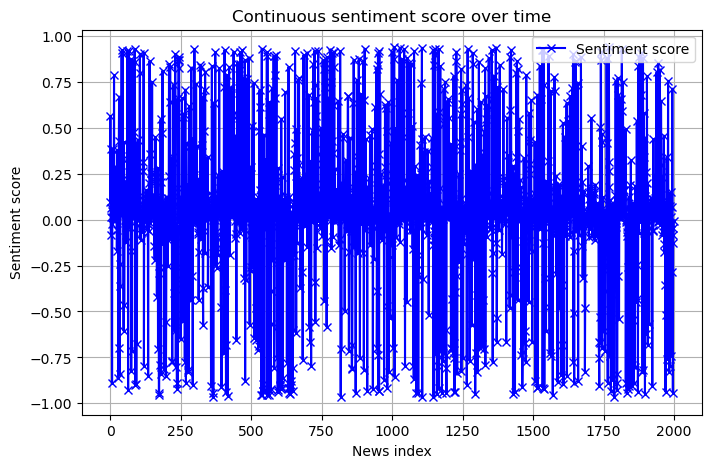

In [3]:
plt.figure(figsize=(8, 5))  # Optional: Adjust the figure size
result_df_subset = result_df.iloc[:2000]
plt.plot(result_df_subset.index, result_df_subset['continuous_score'], label='Sentiment score', color='blue', marker='x')

# Adding labels, title, and legend
plt.xlabel('News index')
plt.ylabel('Sentiment score')
plt.title('Continuous sentiment score over time')
plt.legend()
plt.grid(True)  # Optional: Add gridlines for better readability

# Show the plot
plt.show()

In [4]:
result_df['discrete_score'].value_counts()

discrete_score
 0    27699
-1     6457
 1     5844
Name: count, dtype: int64

In [3]:
daily_sentiment_df = result_df.groupby('seendate').agg(
    discrete_sum=('discrete_score', 'sum'),
    discrete_mean=('discrete_score', 'mean'),
    continuous_sum=('continuous_score', 'sum'),
    continuous_mean=('continuous_score', 'mean')
).reset_index()
# Display the resulting DataFrame
print(daily_sentiment_df)

      seendate  discrete_sum  discrete_mean  continuous_sum  continuous_mean
0   2021-03-31            -8      -0.012195       20.037238         0.030545
1   2021-04-01            32       0.049080       49.880468         0.076504
2   2021-04-02            -5      -0.009042       14.408812         0.026056
3   2021-04-03            -4      -0.009975        6.344996         0.015823
4   2021-04-04            -3      -0.010830        9.606335         0.034680
..         ...           ...            ...             ...              ...
65  2021-06-04           -13      -0.017906       -0.020297        -0.000028
66  2021-06-05           -18      -0.039823       -4.527028        -0.010016
67  2021-06-06            -9      -0.023560        0.690823         0.001808
68  2021-06-07           -22      -0.032885       -1.567765        -0.002343
69  2021-06-08           -37      -0.065026      -19.907552        -0.034987

[70 rows x 5 columns]


In [4]:
import numpy as np

# Using numpy to create the 'daily_sentiment' column based on 'daily_score_sum'
daily_sentiment_df['discrete_sign'] = np.sign(daily_sentiment_df['discrete_sum'])
daily_sentiment_df

,seendate,discrete_sum,discrete_mean,continuous_sum,continuous_mean,discrete_sign
0,2021-03-31,-8,-0.012195,20.037238,0.030545,-1
1,2021-04-01,32,0.049080,49.880468,0.076504,1
2,2021-04-02,-5,-0.009042,14.408812,0.026056,-1
3,2021-04-03,-4,-0.009975,6.344996,0.015823,-1
4,2021-04-04,-3,-0.010830,9.606335,0.034680,-1
...,...,...,...,...,...,...
65,2021-06-04,-13,-0.017906,-0.020297,-0.000028,-1
66,2021-06-05,-18,-0.039823,-4.527028,-0.010016,-1
67,2021-06-06,-9,-0.023560,0.690823,0.001808,-1
68,2021-06-07,-22,-0.032885,-1.567765,-0.002343,-1


In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

daily_sentiment_df['countinuous_sum_sigmoid'] = daily_sentiment_df['continuous_sum'].apply(sigmoid)*2 -1
daily_sentiment_df

,seendate,discrete_sum,discrete_mean,continuous_sum,continuous_mean,discrete_sign,countinuous_sum_sigmoid
0,2021-03-31,-8,-0.012195,20.037238,0.030545,-1,1.000000
1,2021-04-01,32,0.049080,49.880468,0.076504,1,1.000000
2,2021-04-02,-5,-0.009042,14.408812,0.026056,-1,0.999999
3,2021-04-03,-4,-0.009975,6.344996,0.015823,-1,0.996495
4,2021-04-04,-3,-0.010830,9.606335,0.034680,-1,0.999865
...,...,...,...,...,...,...,...
65,2021-06-04,-13,-0.017906,-0.020297,-0.000028,-1,-0.010148
66,2021-06-05,-18,-0.039823,-4.527028,-0.010016,-1,-0.978606
67,2021-06-06,-9,-0.023560,0.690823,0.001808,-1,0.332300
68,2021-06-07,-22,-0.032885,-1.567765,-0.002343,-1,-0.654930


In [6]:
price_df = pd.read_csv('returns_40000.csv')
price_df = price_df.iloc[:, [0,1,2,4]]
price_df

,Date,Close,1dayreturn,1weekreturn
0,2021-03-31T23:00:00.000Z,59095.81,0.488190,-1.306116
1,2021-04-01T23:00:00.000Z,59384.31,-2.998132,-1.918537
2,2021-04-02T23:00:00.000Z,57603.89,2.004483,3.800681
3,2021-04-03T23:00:00.000Z,58758.55,0.509424,2.461616
4,2021-04-04T23:00:00.000Z,59057.88,-1.465545,1.414832
...,...,...,...,...
65,2021-06-04T23:00:00.000Z,35551.96,0.873145,0.001575
66,2021-06-05T23:00:00.000Z,35862.38,-6.418063,9.021933
67,2021-06-06T23:00:00.000Z,33560.71,-0.262450,19.837989
68,2021-06-07T23:00:00.000Z,33472.63,11.569124,20.714357


In [7]:
price_df['1_sigmoid'] = price_df['1dayreturn'].apply(sigmoid)*2 -1
price_df['7_sigmoid'] = price_df['1weekreturn'].apply(sigmoid)*2 -1
price_df['1_[-1, 0, 1]'] = np.sign(price_df['1dayreturn'])
price_df['7_[-1, 0, 1]'] = np.sign(price_df['1weekreturn'])
price_df

,Date,Close,1dayreturn,1weekreturn,1_sigmoid,7_sigmoid,"1_[-1, 0, 1]","7_[-1, 0, 1]"
0,2021-03-31T23:00:00.000Z,59095.81,0.488190,-1.306116,0.239360,-0.573725,1.0,-1.0
1,2021-04-01T23:00:00.000Z,59384.31,-2.998132,-1.918537,-0.904979,-0.743950,-1.0,-1.0
2,2021-04-02T23:00:00.000Z,57603.89,2.004483,3.800681,0.762534,0.956267,1.0,1.0
3,2021-04-03T23:00:00.000Z,58758.55,0.509424,2.461616,0.249343,0.842814,1.0,1.0
4,2021-04-04T23:00:00.000Z,59057.88,-1.465545,1.414832,-0.624759,0.609054,-1.0,1.0
...,...,...,...,...,...,...,...,...
65,2021-06-04T23:00:00.000Z,35551.96,0.873145,0.001575,0.410799,0.000788,1.0,1.0
66,2021-06-05T23:00:00.000Z,35862.38,-6.418063,9.021933,-0.996742,0.999759,-1.0,1.0
67,2021-06-06T23:00:00.000Z,33560.71,-0.262450,19.837989,-0.130477,1.000000,-1.0,1.0
68,2021-06-07T23:00:00.000Z,33472.63,11.569124,20.714357,0.999981,1.000000,1.0,1.0


In [8]:
daily_sentiment_df

,seendate,discrete_sum,discrete_mean,continuous_sum,continuous_mean,discrete_sign,countinuous_sum_sigmoid
0,2021-03-31,-8,-0.012195,20.037238,0.030545,-1,1.000000
1,2021-04-01,32,0.049080,49.880468,0.076504,1,1.000000
2,2021-04-02,-5,-0.009042,14.408812,0.026056,-1,0.999999
3,2021-04-03,-4,-0.009975,6.344996,0.015823,-1,0.996495
4,2021-04-04,-3,-0.010830,9.606335,0.034680,-1,0.999865
...,...,...,...,...,...,...,...
65,2021-06-04,-13,-0.017906,-0.020297,-0.000028,-1,-0.010148
66,2021-06-05,-18,-0.039823,-4.527028,-0.010016,-1,-0.978606
67,2021-06-06,-9,-0.023560,0.690823,0.001808,-1,0.332300
68,2021-06-07,-22,-0.032885,-1.567765,-0.002343,-1,-0.654930


In [9]:
# Define tables
table1 = daily_sentiment_df.iloc[:,1:]

table2 = price_df.iloc[:,2:]

# Reset index to ensure alignment
table1 = table1.reset_index(drop=True)
table2 = table2.reset_index(drop=True)

# Compute correlation
full_df = pd.concat([table1, table2], axis=1)
correlation_matrix = full_df.corr().loc[table1.columns, table2.columns]

# Increase width
pd.set_option('display.width', 1000)  

print(correlation_matrix)

                         1dayreturn  1weekreturn  1_sigmoid  7_sigmoid  1_[-1, 0, 1]  7_[-1, 0, 1]
discrete_sum               0.141978    -0.063382   0.070468  -0.023753      0.071693     -0.045243
discrete_mean              0.115616    -0.059183   0.045612   0.015625      0.051524      0.001379
continuous_sum             0.135356    -0.067147   0.069486  -0.019242      0.077269     -0.052521
continuous_mean            0.185284    -0.052727   0.101695   0.036155      0.100714      0.010927
discrete_sign             -0.054597    -0.120876  -0.108317  -0.163516     -0.099688     -0.182223
countinuous_sum_sigmoid    0.014539    -0.063131  -0.051944   0.027417     -0.035090     -0.002765


In [10]:
max_value = correlation_matrix.abs().max().max()  # Get the overall max value
print(max_value)

# Use stack to find the position of the max value
max_position = (correlation_matrix.abs() == max_value).stack()

# Get the row and column of the max value (first occurrence)
row_idx, col_idx = max_position.idxmax()

print(f"Max Correlation: {round(max_value,3)}")
print(f"Between: {row_idx} & {col_idx}")

0.18528388746135982
Max Correlation: 0.185
Between: continuous_mean & 1dayreturn


### The next step is to build a trading signal. The max correlation is obtained between continuous_mean and 1 day return.

In [11]:
trade_df = pd.DataFrame()
trade_df['date'] = daily_sentiment_df['seendate']
trade_df['price'] = price_df['Close']
trade_df[['sentiment_continuous_mean']] = full_df[['continuous_mean']]
trade_df

,date,price,sentiment_continuous_mean
0,2021-03-31,59095.81,0.030545
1,2021-04-01,59384.31,0.076504
2,2021-04-02,57603.89,0.026056
3,2021-04-03,58758.55,0.015823
4,2021-04-04,59057.88,0.034680
...,...,...,...
65,2021-06-04,35551.96,-0.000028
66,2021-06-05,35862.38,-0.010016
67,2021-06-06,33560.71,0.001808
68,2021-06-07,33472.63,-0.002343


In [12]:
# Suppose we have 100 euro at the start. So we can buy 100/59095.81 bitcoin at the first day.

start_money = 100


In [13]:

trade_df['profit_1'] = (trade_df['price'] - trade_df['price'].iloc[0]) * start_money / trade_df['price'][0]
trade_df['return_1'] = trade_df['profit_1'] / start_money * 100

trade_df


,date,price,sentiment_continuous_mean,profit_1,return_1
0,2021-03-31,59095.81,0.030545,0.000000,0.000000
1,2021-04-01,59384.31,0.076504,0.488190,0.488190
2,2021-04-02,57603.89,0.026056,-2.524578,-2.524578
3,2021-04-03,58758.55,0.015823,-0.570700,-0.570700
4,2021-04-04,59057.88,0.034680,-0.064184,-0.064184
...,...,...,...,...,...
65,2021-06-04,35551.96,-0.000028,-39.840134,-39.840134
66,2021-06-05,35862.38,-0.010016,-39.314852,-39.314852
67,2021-06-06,33560.71,0.001808,-43.209662,-43.209662
68,2021-06-07,33472.63,-0.002343,-43.358709,-43.358709


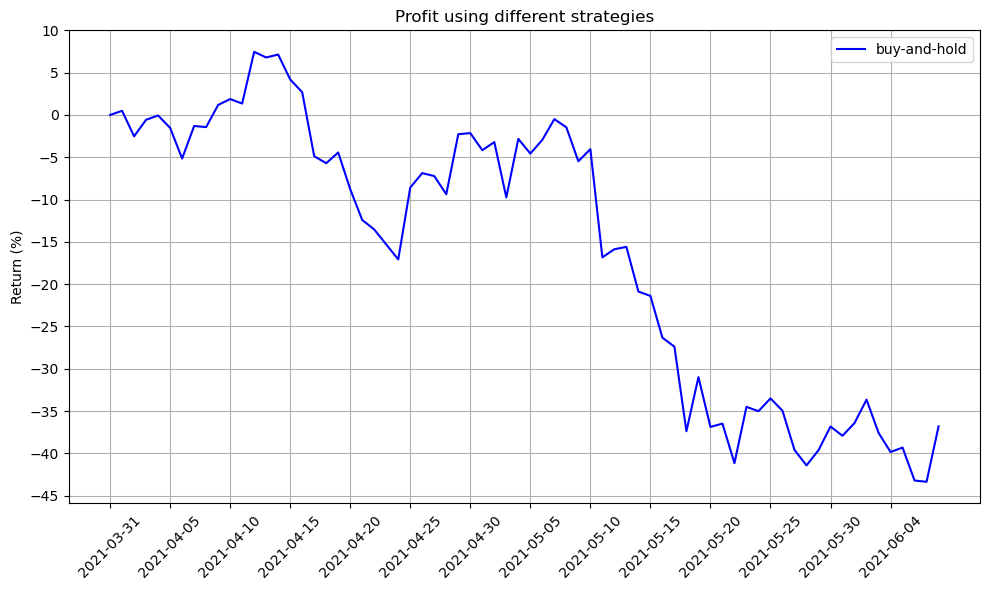

In [21]:
# Plotting the profit/loss over time
plt.figure(figsize=(10, 6))
plt.plot(trade_df['date'], trade_df['return_1'], label='buy-and-hold', color='blue')
plt.title('Profit using different strategies')
plt.ylabel('Return (%)')
# y_min, y_max = trade_df['return_1'].min(), trade_df['return_1'].max()
plt.yticks(np.linspace(-45, 10, num=12))  # Adjust `num=10` for desired density

plt.xticks(trade_df['date'][::5], rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the trading signal based on sentiment_continuous_mean
# Buy when sentiment_continuous_mean > 0.05, Sell otherwise

threshold = 0.05

trade_df['signal'] = 'Sell'
trade_df.loc[trade_df['sentiment_continuous_mean'] > threshold, 'signal'] = 'Buy'

# Calculate profit/loss based on holding a product with a sentiment signal
trade_df


,date,price,sentiment_continuous_mean,profit_1,return_1,signal
0,2021-03-31,59095.81,0.030545,0.000000,0.000000,Sell
1,2021-04-01,59384.31,0.076504,0.488190,0.488190,Buy
2,2021-04-02,57603.89,0.026056,-2.524578,-2.524578,Sell
3,2021-04-03,58758.55,0.015823,-0.570700,-0.570700,Sell
4,2021-04-04,59057.88,0.034680,-0.064184,-0.064184,Sell
...,...,...,...,...,...,...
65,2021-06-04,35551.96,-0.000028,-39.840134,-39.840134,Sell
66,2021-06-05,35862.38,-0.010016,-39.314852,-39.314852,Sell
67,2021-06-06,33560.71,0.001808,-43.209662,-43.209662,Sell
68,2021-06-07,33472.63,-0.002343,-43.358709,-43.358709,Sell


In [23]:
holding = False  # Are we holding Bitcoin?
entry_price = 0  # Price at which we bought
trade_df['profit_2'] = 0.0
total_profit = 0.0


for i in range(len(trade_df)):
    if trade_df.loc[i, 'signal'] == 'Buy' and not holding:
        # Buy when sentiment turns positive
        holding = True
        entry_price = trade_df.loc[i, 'price']
    
    elif trade_df.loc[i, 'signal'] == 'Sell' and holding:
        # Sell when sentiment turns negative
        exit_price = trade_df.loc[i, 'price']
        profit = exit_price - entry_price
        total_profit += profit
        holding = False  # No longer holding

    trade_df.loc[i, 'profit_2'] = total_profit * start_money / trade_df.loc[0,'price']
    trade_df.loc[i, 'return_2'] = trade_df.loc[i, 'profit_2'] / start_money * 100
trade_df

,date,price,sentiment_continuous_mean,profit_1,return_1,signal,profit_2,return_2
0,2021-03-31,59095.81,0.030545,0.000000,0.000000,Sell,0.000000,0.000000
1,2021-04-01,59384.31,0.076504,0.488190,0.488190,Buy,0.000000,0.000000
2,2021-04-02,57603.89,0.026056,-2.524578,-2.524578,Sell,-3.012769,-3.012769
3,2021-04-03,58758.55,0.015823,-0.570700,-0.570700,Sell,-3.012769,-3.012769
4,2021-04-04,59057.88,0.034680,-0.064184,-0.064184,Sell,-3.012769,-3.012769
...,...,...,...,...,...,...,...,...
65,2021-06-04,35551.96,-0.000028,-39.840134,-39.840134,Sell,1.871876,1.871876
66,2021-06-05,35862.38,-0.010016,-39.314852,-39.314852,Sell,1.871876,1.871876
67,2021-06-06,33560.71,0.001808,-43.209662,-43.209662,Sell,1.871876,1.871876
68,2021-06-07,33472.63,-0.002343,-43.358709,-43.358709,Sell,1.871876,1.871876


In [24]:
# Apply profit/loss only when there's a Buy signal (assumes buy at that day's price)
# trade_df['loss'] = trade_df.apply(lambda row: row['loss'] if row['signal'] == 'Buy' else 0, axis=1)

trade_df['daily_diff'] = trade_df['price'].diff().shift(-1)  # Price difference for the next day
trade_df.loc[trade_df['signal'] == 'Sell', 'daily_diff'] = 0
# Calculate the cumulative profit/loss
trade_df['profit_3'] = trade_df['daily_diff'].cumsum() * start_money / trade_df['price'][0]
trade_df['return_3'] = trade_df['profit_3'] / start_money * 100
trade_df

,date,price,sentiment_continuous_mean,profit_1,return_1,signal,profit_2,return_2,daily_diff,profit_3,return_3
0,2021-03-31,59095.81,0.030545,0.000000,0.000000,Sell,0.000000,0.000000,0.00,0.000000,0.000000
1,2021-04-01,59384.31,0.076504,0.488190,0.488190,Buy,0.000000,0.000000,-1780.42,-3.012769,-3.012769
2,2021-04-02,57603.89,0.026056,-2.524578,-2.524578,Sell,-3.012769,-3.012769,0.00,-3.012769,-3.012769
3,2021-04-03,58758.55,0.015823,-0.570700,-0.570700,Sell,-3.012769,-3.012769,0.00,-3.012769,-3.012769
4,2021-04-04,59057.88,0.034680,-0.064184,-0.064184,Sell,-3.012769,-3.012769,0.00,-3.012769,-3.012769
...,...,...,...,...,...,...,...,...,...,...,...
65,2021-06-04,35551.96,-0.000028,-39.840134,-39.840134,Sell,1.871876,1.871876,0.00,1.871876,1.871876
66,2021-06-05,35862.38,-0.010016,-39.314852,-39.314852,Sell,1.871876,1.871876,0.00,1.871876,1.871876
67,2021-06-06,33560.71,0.001808,-43.209662,-43.209662,Sell,1.871876,1.871876,0.00,1.871876,1.871876
68,2021-06-07,33472.63,-0.002343,-43.358709,-43.358709,Sell,1.871876,1.871876,0.00,1.871876,1.871876


If today's signal is "Buy" → Profit/loss = Next day's price change.  
If today's signal is "Sell" → Profit/loss = 0 (not holding anything).  
Cumulative profit → The sum of all daily profits over time.

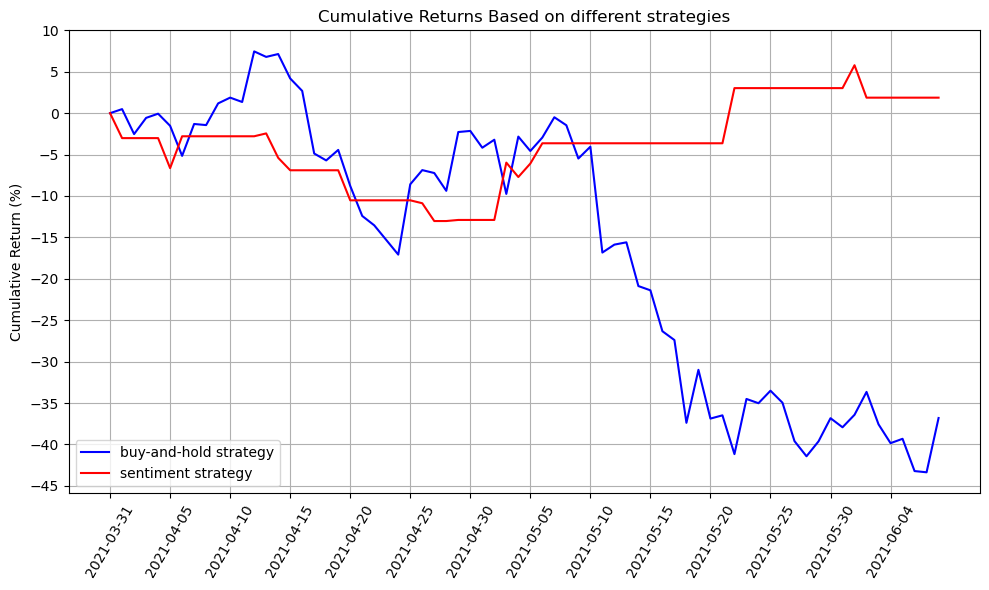

In [28]:
# Plot the cumulative profit/loss
plt.figure(figsize=(10, 6))
plt.plot(trade_df['date'], trade_df['return_1'], label='buy-and-hold strategy', color='blue')
# plt.plot(trade_df['date'], trade_df['return_2'], label='trade daily strategy', color='green')
plt.plot(trade_df['date'], trade_df['return_3'], label='sentiment strategy', color='red')
plt.title('Cumulative Returns Based on different strategies')
plt.xticks(trade_df['date'][::5], rotation=60)
plt.ylabel('Cumulative Return (%)')
plt.yticks(np.linspace(-45, 10, num=12))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

y axis should be percent, i should start 100 euro.
threshold should be 0.25, 0.5, 0.75?
use the last 10 days to predict the next day's price.

#### Separate from the trading signal, did you validate FinBert’s accuracy in predicting sentiment? That is, when manually labeling headlines, how well do the results align with FinBert’s predictions?